<a href="https://colab.research.google.com/github/Andre-Gomez-Serrano/2.2-Actividad-2-An-lisis-de-datos-con-pandas/blob/main/Actividad2AnalisisPandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Carlos André Gómez Serrano
*   MATRÍCULA: A01733624

---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [1]:
# Importa las librerías necesarias
import pandas as pd



In [2]:
weather_df=pd.read_csv("cleaned_weather.csv")

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





In [3]:
weather_df.head( )

,timestamp,p,T,Tpot,rh,VPact,sh,H2OC,rho,wv,wd,rain,raining
0,01/01/20 0:10,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,01/01/20 0:20,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,01/01/20 0:30,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0
3,01/01/20 0:40,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0
4,01/01/20 0:50,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0


In [4]:
weather_df.tail()

,timestamp,p,T,Tpot,rh,VPact,sh,H2OC,rho,wv,wd,rain,raining
52691,31/12/20 23:20,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0
52692,31/12/20 23:30,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0
52693,31/12/20 23:40,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0
52694,31/12/20 23:50,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0
52695,01/01/21 0:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0


In [6]:
print("No hay valores faltantes" if weather_df.isnull().sum().sum() == 0 else "Sí hay valores faltantes")

No hay valores faltantes


2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [16]:
import pandas as pd

print("Tipos de datos originales:")
print(weather_df.dtypes)

weather_df['medicion'] = pd.to_datetime(weather_df['medicion'], format='%d/%m/%y %H:%M')

weather_df['fecha'] = weather_df['medicion'].dt.date
weather_df['hora'] = weather_df['medicion'].dt.time

print("\nTipos de datos después de la conversión y nuevas columnas:")
print(weather_df.dtypes)

Tipos de datos originales:
medicion               datetime64[ns]
presion_atmosferica           float64
temperatura_celsius           float64
temperatura_kelvin            float64
humedad_relativa              float64
presion_vapor                 float64
humedad_especifica            float64
concentracion_vapor           float64
densidad_aire                 float64
velocidad_viento              float64
direccion_viento              float64
precipitacion_total           float64
duracion_lluvia                 int64
fecha                          object
hora                           object
dtype: object

Tipos de datos después de la conversión y nuevas columnas:
medicion               datetime64[ns]
presion_atmosferica           float64
temperatura_celsius           float64
temperatura_kelvin            float64
humedad_relativa              float64
presion_vapor                 float64
humedad_especifica            float64
concentracion_vapor           float64
densidad_aire            

3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [21]:
print("Valores únicos por columna (estado actual):")
print(weather_df.nunique())

# Reconstruir una columna temporal de tipo datetime para verificar duplicados
# usando 'fecha' y 'hora' que son los componentes actuales de la medición de tiempo
weather_df['medicion_temp'] = pd.to_datetime(weather_df['fecha'].astype(str) + ' ' + weather_df['hora'].astype(str))

# Identificar filas duplicadas en la columna 'medicion_temp'
duplicated_entries = weather_df[weather_df.duplicated('medicion_temp', keep=False)]

if not duplicated_entries.empty:
    print("\nFechas y horas duplicadas en la columna temporal 'medicion_temp':")
    print(duplicated_entries[['medicion_temp', 'fecha', 'hora']])
    print("\nComprobando si las columnas restantes también son idénticas para los registros duplicados...")
    # Check if all columns are identical for these duplicated 'medicion_temp' entries
    if duplicated_entries.duplicated().any():
        print("Se encontraron registros completamente duplicados. Eliminando uno de ellos.")
        weather_df.drop_duplicates(subset='medicion_temp', inplace=True)
        print(f"Dimensionalidad después de eliminar duplicados: {weather_df.shape}")
    else:
        print("Los registros con fechas y horas duplicadas no son idénticos en todas las columnas.")
else:
    print("\nNo se encontraron fechas y horas duplicadas en la combinación 'fecha' y 'hora'.")
    print("Esto es esperado, ya que los duplicados de la columna 'medicion' original fueron eliminados en un paso previo.")

# Eliminar la columna temporal 'medicion_temp'
weather_df = weather_df.drop('medicion_temp', axis=1)

print("\nValores únicos por columna después de la verificación/limpieza (si aplica):")
print(weather_df.nunique())

print("\nPrimeros 5 registros del dataframe después de las operaciones:")
display(weather_df.head())

Valores únicos por columna (estado actual):
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
fecha                    366
hora                     144
dtype: int64

No se encontraron fechas y horas duplicadas en la combinación 'fecha' y 'hora'.
Esto es esperado, ya que los duplicados de la columna 'medicion' original fueron eliminados en un paso previo.

Valores únicos por columna después de la verificación/limpieza (si aplica):
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direcci

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
0,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0,2020-01-01,00:10:00
1,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0,2020-01-01,00:20:00
2,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0,2020-01-01,00:30:00
3,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0,2020-01-01,00:40:00
4,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0,2020-01-01,00:50:00


4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [20]:
# '¿Por qué son 144 horas diferentes?'
print("\nRespuesta: Hay 144 horas diferentes porque los datos se registran cada 10 minutos en un período de 24 horas. 24 horas * 60 minutos/hora / 10 minutos/medición = 144 mediciones por día.")

# Recrear una columna de tipo datetime para las operaciones, asumiendo que 'medicion' fue eliminada
# y que 'fecha' y 'hora' están disponibles como objetos.
weather_df['medicion_reconstructed'] = pd.to_datetime(weather_df['fecha'].astype(str) + ' ' + weather_df['hora'].astype(str))

# Identificar mediciones faltantes
min_date = weather_df['medicion_reconstructed'].min()
max_date = weather_df['medicion_reconstructed'].max()
full_time_range = pd.date_range(start=min_date, end=max_date, freq='10min')

missing_times = pd.Series(full_time_range).loc[~pd.Series(full_time_range).isin(weather_df['medicion_reconstructed'])]

if not missing_times.empty:
    print(f"\nNúmero de mediciones faltantes: {len(missing_times)}")
    print("Primeras 5 mediciones faltantes:")
    print(missing_times.head())
else:
    print("\nNo se encontraron mediciones faltantes en la secuencia de tiempo.")

# Eliminar registros que no corresponden al año 2020
initial_shape = weather_df.shape[0]
weather_df = weather_df[weather_df['medicion_reconstructed'].dt.year == 2020]
final_shape = weather_df.shape[0]

print(f"\nSe eliminaron {initial_shape - final_shape} registros fuera del año 2020.")

# Eliminar la columna 'medicion_reconstructed' (que actúa como reemplazo de la original 'medicion')
weather_df = weather_df.drop('medicion_reconstructed', axis=1)
print("Columna 'medicion_reconstructed' (anteriormente 'medicion') eliminada.")

print("\nPrimeros 5 registros del dataframe después de las operaciones:")
print(weather_df.head())
print("\nÚltimos 5 registros del dataframe después de las operaciones:")
print(weather_df.tail())


Respuesta: Hay 144 horas diferentes porque los datos se registran cada 10 minutos en un período de 24 horas. 24 horas * 60 minutos/hora / 10 minutos/medición = 144 mediciones por día.

Número de mediciones faltantes: 9
Primeras 5 mediciones faltantes:
21513   2020-05-29 09:40:00
21514   2020-05-29 09:50:00
21515   2020-05-29 10:00:00
21516   2020-05-29 10:10:00
21517   2020-05-29 10:20:00
dtype: datetime64[ns]

Se eliminaron 0 registros fuera del año 2020.
Columna 'medicion_reconstructed' (anteriormente 'medicion') eliminada.

Primeros 5 registros del dataframe después de las operaciones:
   presion_atmosferica  temperatura_celsius  temperatura_kelvin  \
0              1008.89                 0.71              273.18   
1              1008.76                 0.75              273.22   
2              1008.66                 0.73              273.21   
3              1008.64                 0.37              272.86   
4              1008.61                 0.33              272.82   



5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [23]:
# Agrupar por 'fecha' y obtener el máximo de cada columna numérica
# Excluimos 'fecha' y 'hora' de la agregación ya que son columnas creadas o ya utilizadas para agrupar
indicadores_diarios = weather_df.groupby('fecha').max().reset_index()

print("Primeros 5 registros del dataframe indicadores_diarios:")
print(indicadores_diarios.head())

# ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
max_precipitacion = indicadores_diarios['precipitacion_total'].max()
fecha_max_precipitacion = indicadores_diarios.loc[indicadores_diarios['precipitacion_total'] == max_precipitacion, 'fecha'].iloc[0]
print(f"\nLa máxima precipitación fue de {max_precipitacion} mm y ocurrió el {fecha_max_precipitacion}.")

# ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
top_3_viento = indicadores_diarios.nlargest(3, 'velocidad_viento')[['fecha', 'velocidad_viento']]
print("\nLos tres días con las velocidades de viento más altas fueron:")
print(top_3_viento)

# ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?
dias_condicion = indicadores_diarios[(indicadores_diarios['humedad_relativa'] > 90) & (indicadores_diarios['temperatura_celsius'] > 30)]
num_dias_condicion = len(dias_condicion)
print(f"\nNúmero de días que rebasaron el 90% de humedad relativa y los 30° Celsius: {num_dias_condicion}")

Primeros 5 registros del dataframe indicadores_diarios:
        fecha  presion_atmosferica  temperatura_celsius  temperatura_kelvin  \
0  2020-01-01              1008.89                 4.58              277.27   
1  2020-01-02              1004.16                 6.47              279.72   
2  2020-01-03               998.45                 8.17              281.80   
3  2020-01-04              1003.47                 6.61              280.15   
4  2020-01-05              1009.07                 4.43              277.01   

   humedad_relativa  presion_vapor  humedad_especifica  concentracion_vapor  \
0              95.0           5.81                3.60                 5.77   
1              93.9           5.57                3.48                 5.58   
2              89.3           9.34                5.86                 9.39   
3              91.4           8.54                5.36                 8.58   
4              85.3           6.44                3.99                 6.4

In [28]:


# Agrupar por 'fecha' y obtener el máximo de cada columna numérica
# Excluimos 'fecha' y 'hora' de la agregación ya que son columnas creadas o ya utilizadas para agrupar
indicadores_diarios = weather_df.groupby('fecha').max().reset_index()

print("Primeros 5 registros del dataframe indicadores_diarios:")
print(indicadores_diarios.head())

# ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
max_precipitacion = indicadores_diarios['precipitacion_total'].max()
fecha_max_precipitacion = indicadores_diarios.loc[indicadores_diarios['precipitacion_total'] == max_precipitacion, 'fecha'].iloc[0]
print(f"\nLa máxima precipitación fue de {max_precipitacion} mm y ocurrió el {fecha_max_precipitacion}.")

# ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
top_3_viento = indicadores_diarios.nlargest(3, 'velocidad_viento')[['fecha', 'velocidad_viento']]
print("\nLos tres días con las velocidades de viento más altas fueron:")
print(top_3_viento)

# ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?
dias_condicion = indicadores_diarios[(indicadores_diarios['humedad_relativa'] > 90) & (indicadores_diarios['temperatura_celsius'] > 30)]
num_dias_condicion = len(dias_condicion)
print(f"\nNúmero de días que rebasaron el 90% de humedad relativa y los 30° Celsius: {num_dias_condicion}")

Primeros 5 registros del dataframe indicadores_diarios:
        fecha  presion_atmosferica  temperatura_celsius  temperatura_kelvin  \
0  2020-01-01              1008.89                 4.58              277.27   
1  2020-01-02              1004.16                 6.47              279.72   
2  2020-01-03               998.45                 8.17              281.80   
3  2020-01-04              1003.47                 6.61              280.15   
4  2020-01-05              1009.07                 4.43              277.01   

   humedad_relativa  presion_vapor  humedad_especifica  concentracion_vapor  \
0              95.0           5.81                3.60                 5.77   
1              93.9           5.57                3.48                 5.58   
2              89.3           9.34                5.86                 9.39   
3              91.4           8.54                5.36                 8.58   
4              85.3           6.44                3.99                 6.4

In [29]:
# Aplicar describe() al dataframe indicadores_diarios
desc_stats = indicadores_diarios.describe()
print("Estadísticas descriptivas para indicadores_diarios:")
display(desc_stats)

# ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
std_concentracion_vapor = desc_stats.loc['std', 'concentracion_vapor']
print(f"\nDesviación estándar de la concentración de vapor: {std_concentracion_vapor:.2f}")
print("Interpretación: Este valor indica la dispersión promedio de la concentración de vapor con respecto a su media diaria máxima. Un valor bajo sugiere que las concentraciones máximas diarias de vapor tienden a ser consistentes, mientras que un valor alto indicaría una mayor variabilidad.")

# ¿Cuál es la mediana de la presión atmosférica y qué significa?
mediana_presion_atmosferica = desc_stats.loc['50%', 'presion_atmosferica']
print(f"\nMediana de la presión atmosférica: {mediana_presion_atmosferica:.2f}")
print("Interpretación: La mediana representa el valor central de la presión atmosférica máxima diaria. El 50% de los días tuvieron una presión atmosférica máxima igual o inferior a este valor, y el otro 50% tuvieron una presión igual o superior.")

# ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?
tercer_cuartil_duracion_lluvia = desc_stats.loc['75%', 'duracion_lluvia']
print(f"\nTercer cuartil de la duración de la lluvia: {tercer_cuartil_duracion_lluvia:.2f}")
print("Interpretación: Esto significa que el 75% de los días tuvieron una duración máxima de lluvia igual o inferior a este valor. También implica que el 25% de los días con mayor duración de lluvia superaron este valor.")

Estadísticas descriptivas para indicadores_diarios:


,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,992.977842,15.343770,289.431667,90.886530,11.409454,7.214016,11.539180,1232.622814,5.245164,317.673689,0.314208,240.382514
std,8.543447,7.850339,7.942175,9.201588,4.507555,2.872647,4.573267,32.702446,2.097012,50.611324,0.979721,273.840002
min,959.900000,-0.120000,273.460000,55.440000,3.320000,2.050000,3.290000,1167.050000,1.570000,69.570000,0.000000,0.000000
25%,988.015000,8.840000,282.732500,85.400000,7.647500,4.832500,7.742500,1207.590000,3.662500,279.075000,0.000000,0.000000
50%,993.300000,15.060000,289.160000,93.250000,10.715000,6.705000,10.735000,1231.455000,4.880000,346.650000,0.000000,0.000000
75%,998.432500,21.695000,295.957500,99.900000,14.462500,9.180000,14.685000,1256.057500,6.495000,357.300000,0.200000,600.000000
max,1020.070000,34.800000,309.130000,100.000000,24.160000,15.400000,24.530000,1318.520000,13.770000,360.000000,11.200000,600.000000



Desviación estándar de la concentración de vapor: 4.57
Interpretación: Este valor indica la dispersión promedio de la concentración de vapor con respecto a su media diaria máxima. Un valor bajo sugiere que las concentraciones máximas diarias de vapor tienden a ser consistentes, mientras que un valor alto indicaría una mayor variabilidad.

Mediana de la presión atmosférica: 993.30
Interpretación: La mediana representa el valor central de la presión atmosférica máxima diaria. El 50% de los días tuvieron una presión atmosférica máxima igual o inferior a este valor, y el otro 50% tuvieron una presión igual o superior.

Tercer cuartil de la duración de la lluvia: 600.00
Interpretación: Esto significa que el 75% de los días tuvieron una duración máxima de lluvia igual o inferior a este valor. También implica que el 25% de los días con mayor duración de lluvia superaron este valor.


6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [26]:
# Aplicar describe() al dataframe indicadores_diarios
desc_stats = indicadores_diarios.describe()
print("Estadísticas descriptivas para indicadores_diarios:")
display(desc_stats)

# ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
std_concentracion_vapor = desc_stats.loc['std', 'concentracion_vapor']
print(f"\nDesviación estándar de la concentración de vapor: {std_concentracion_vapor:.2f}")
print("Interpretación: Este valor indica la dispersión promedio de la concentración de vapor con respecto a su media diaria máxima. Un valor bajo sugiere que las concentraciones máximas diarias de vapor tienden a ser consistentes, mientras que un valor alto indicaría una mayor variabilidad.")

# ¿Cuál es la mediana de la presión atmosférica y qué significa?
mediana_presion_atmosferica = desc_stats.loc['50%', 'presion_atmosferica']
print(f"\nMediana de la presión atmosférica: {mediana_presion_atmosferica:.2f}")
print("Interpretación: La mediana representa el valor central de la presión atmosférica máxima diaria. El 50% de los días tuvieron una presión atmosférica máxima igual o inferior a este valor, y el otro 50% tuvieron una presión igual o superior.")

# ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?
tercer_cuartil_duracion_lluvia = desc_stats.loc['75%', 'duracion_lluvia']
print(f"\nTercer cuartil de la duración de la lluvia: {tercer_cuartil_duracion_lluvia:.2f}")
print("Interpretación: Esto significa que el 75% de los días tuvieron una duración máxima de lluvia igual o inferior a este valor. También implica que el 25% de los días con mayor duración de lluvia superaron este valor.")

Estadísticas descriptivas para indicadores_diarios:


,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,992.977842,15.343770,289.431667,90.886530,11.409454,7.214016,11.539180,1232.622814,5.245164,317.673689,0.314208,240.382514
std,8.543447,7.850339,7.942175,9.201588,4.507555,2.872647,4.573267,32.702446,2.097012,50.611324,0.979721,273.840002
min,959.900000,-0.120000,273.460000,55.440000,3.320000,2.050000,3.290000,1167.050000,1.570000,69.570000,0.000000,0.000000
25%,988.015000,8.840000,282.732500,85.400000,7.647500,4.832500,7.742500,1207.590000,3.662500,279.075000,0.000000,0.000000
50%,993.300000,15.060000,289.160000,93.250000,10.715000,6.705000,10.735000,1231.455000,4.880000,346.650000,0.000000,0.000000
75%,998.432500,21.695000,295.957500,99.900000,14.462500,9.180000,14.685000,1256.057500,6.495000,357.300000,0.200000,600.000000
max,1020.070000,34.800000,309.130000,100.000000,24.160000,15.400000,24.530000,1318.520000,13.770000,360.000000,11.200000,600.000000



Desviación estándar de la concentración de vapor: 4.57
Interpretación: Este valor indica la dispersión promedio de la concentración de vapor con respecto a su media diaria máxima. Un valor bajo sugiere que las concentraciones máximas diarias de vapor tienden a ser consistentes, mientras que un valor alto indicaría una mayor variabilidad.

Mediana de la presión atmosférica: 993.30
Interpretación: La mediana representa el valor central de la presión atmosférica máxima diaria. El 50% de los días tuvieron una presión atmosférica máxima igual o inferior a este valor, y el otro 50% tuvieron una presión igual o superior.

Tercer cuartil de la duración de la lluvia: 600.00
Interpretación: Esto significa que el 75% de los días tuvieron una duración máxima de lluvia igual o inferior a este valor. También implica que el 25% de los días con mayor duración de lluvia superaron este valor.


7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

array([[<Axes: title={'center': 'presion_atmosferica'}>,
        <Axes: title={'center': 'temperatura_celsius'}>,
        <Axes: title={'center': 'temperatura_kelvin'}>],
       [<Axes: title={'center': 'humedad_relativa'}>,
        <Axes: title={'center': 'presion_vapor'}>,
        <Axes: title={'center': 'humedad_especifica'}>],
       [<Axes: title={'center': 'concentracion_vapor'}>,
        <Axes: title={'center': 'densidad_aire'}>,
        <Axes: title={'center': 'velocidad_viento'}>],
       [<Axes: title={'center': 'direccion_viento'}>,
        <Axes: title={'center': 'precipitacion_total'}>,
        <Axes: title={'center': 'duracion_lluvia'}>]], dtype=object)

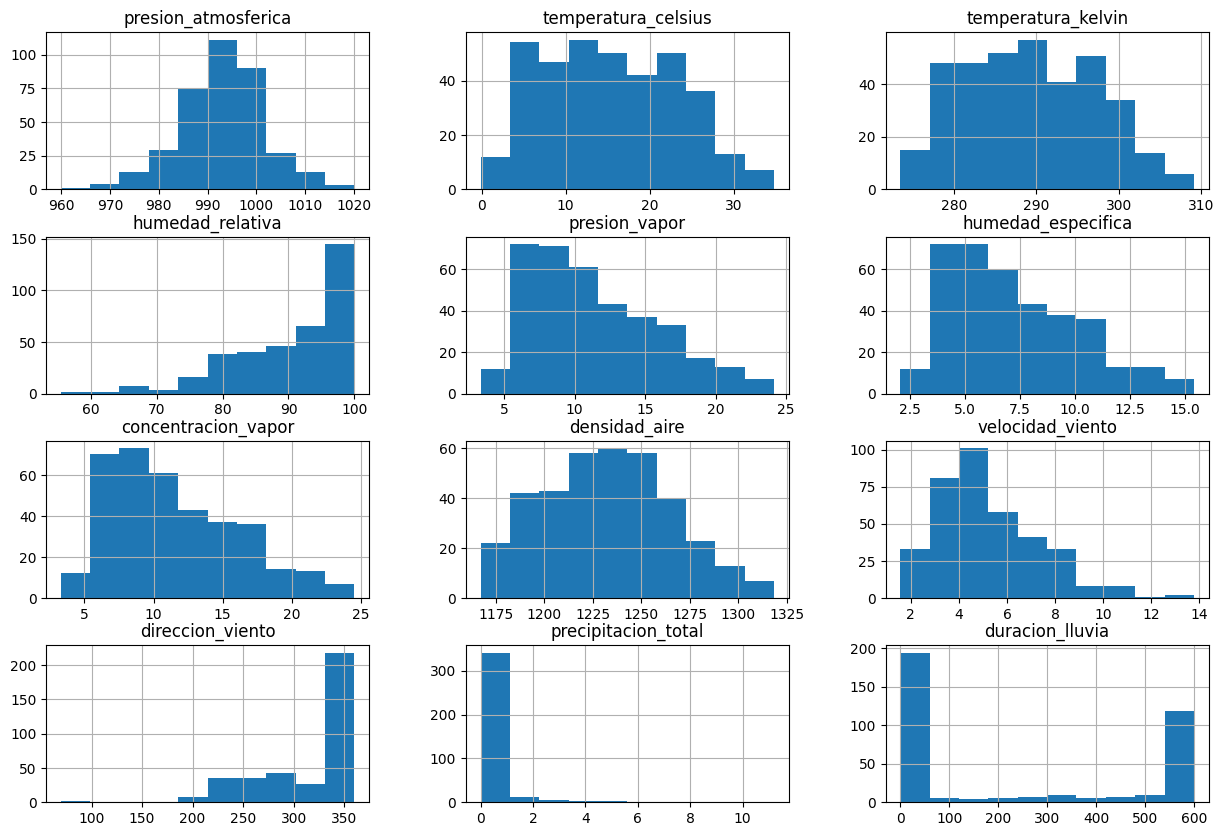

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [34]:
# Poner formato datetime a indicadores diarios
indicadores_diarios['fecha'] = pd.to_datetime(indicadores_diarios['fecha'])

# Nueva columna 'mes' a partir de la fecha
indicadores_diarios['mes'] = indicadores_diarios['fecha'].dt.month

# grupo por 'mes' y cálculo de los promedios mensuales
indicadores_mensuales = indicadores_diarios.groupby('mes')[[ 'humedad_relativa', 'temperatura_celsius', 'velocidad_viento']].mean().reset_index()

print("Primeros 5 registros del dataframe indicadores_mensuales:")
display(indicadores_mensuales.head())

Primeros 5 registros del dataframe indicadores_mensuales:


,mes,humedad_relativa,temperatura_celsius,velocidad_viento
0,1,89.776129,6.821290,5.031935
1,2,85.719655,8.962414,7.489655
2,3,85.372903,9.683871,6.421290
3,4,80.938667,16.879667,4.997000
4,5,87.464839,17.135484,4.865806


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [38]:

# Crear una columna 'mes' para la pivot_table
if 'mes' not in indicadores_diarios.columns:
    indicadores_diarios['mes'] = indicadores_diarios['fecha'].dt.month

# Construir el dataframe mensual utilizando pivot_table()
# Agrupamos por 'mes' y obtenemos el promedio de las columnas seleccionadas
indicadores_mensuales_pivot = indicadores_diarios.pivot_table(
    index='mes',
    values=['humedad_relativa', 'temperatura_celsius', 'velocidad_viento'],
    aggfunc='mean'
).reset_index()

# Calcular el índice de calor de Thom (TDI)
# TDI = temperatura_celsius + 0.33 * humedad_relativa - 0.7 * velocidad_viento - 4
indicadores_mensuales_pivot['indice_calor'] = (
    indicadores_mensuales_pivot['temperatura_celsius'] +
    0.33 * indicadores_mensuales_pivot['humedad_relativa'] -
    0.7 * indicadores_mensuales_pivot['velocidad_viento'] - 4
)

print("DataFrame indicadores_mensuales_pivot con el índice de calor de Thom:")
display(indicadores_mensuales_pivot.head())

DataFrame indicadores_mensuales_pivot con el índice de calor de Thom:


,mes,humedad_relativa,temperatura_celsius,velocidad_viento,indice_calor
0,1,89.776129,6.821290,5.031935,28.925058
1,2,85.719655,8.962414,7.489655,28.007141
2,3,85.372903,9.683871,6.421290,29.362026
3,4,80.938667,16.879667,4.997000,36.091527
4,5,87.464839,17.135484,4.865806,38.592816


10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [39]:
print("\nTransformando con melt():")
indicadores_mensuales_melt = indicadores_mensuales_pivot.melt(
    id_vars=['mes'],
    value_vars=['humedad_relativa', 'temperatura_celsius', 'velocidad_viento', 'indice_calor'],
    var_name='indicador',
    value_name='valor'
)
display(indicadores_mensuales_melt.head())


Transformando con melt():


,mes,indicador,valor
0,1,humedad_relativa,89.776129
1,2,humedad_relativa,85.719655
2,3,humedad_relativa,85.372903
3,4,humedad_relativa,80.938667
4,5,humedad_relativa,87.464839


In [40]:
print("\nTransformando con stack():")
indicadores_mensuales_stacked = indicadores_mensuales_pivot.set_index('mes').stack().reset_index()
indicadores_mensuales_stacked.rename(columns={'level_1': 'indicador', 0: 'valor'}, inplace=True)
display(indicadores_mensuales_stacked.head())


Transformando con stack():


,mes,indicador,valor
0,1,humedad_relativa,89.776129
1,1,temperatura_celsius,6.821290
2,1,velocidad_viento,5.031935
3,1,indice_calor,28.925058
4,2,humedad_relativa,85.719655


Diferencias clave

*   melt(): Es como reorganizar una tabla. Tú le dices cuáles columnas son tus identificadores (como el mes) y cuáles son los valores que quieres 'desapilar' en nuevas filas (como humedad, temperatura, etc.). Es muy flexible y fácil de controlar para la mayoría de los casos.

*   stack(): Funciona mejor cuando tus columnas ya tienen una estructura jerárquica (MultiIndex). Básicamente, toma el último nivel de las columnas y lo convierte en filas. Si tus columnas no son jerárquicas, stack() 'apila' todas las columnas no-índice. Para que funcionara como melt() en nuestro ejemplo, tuvimos que preparar el DataFrame haciendo que mes fuera el índice primero.

---

**Declaración de uso de IA**

Bibliografía:

*   OpenAI. (2026). *ChatGPT (basado en GPT-4)* [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://chat.openai.com/

* Anthropic. (2026, 26 de septiembre). Claude 3.5 Sonnet [Modelo de lenguaje grande]. claude.ai, utlizado para generación de código y depuración. https://claude.ai/

* Google. (2026, 26 de septiembre). Gemini 1.5 Pro [Chat de IA generativa]. Utilizado para corrección y ejecución de errores. https://gemini.google.com/

---